<a href="https://colab.research.google.com/github/danielmarin030513-ctrl/Ai-Project-TAM400-Daniel.M-Oskar.A/blob/main/TAM400_Project_Cleaned_Version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import kagglehub
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [32]:
path = kagglehub.dataset_download(
    "fedesoriano/heart-failure-prediction"
)

df = pd.read_csv(f"{path}/heart.csv")

print("Dataset Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Dataset Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [33]:
df.info()

df.describe()

print("Missing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpea

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>,
        <Axes: title={'center': 'Cholesterol'}>],
       [<Axes: title={'center': 'FastingBS'}>,
        <Axes: title={'center': 'MaxHR'}>,
        <Axes: title={'center': 'Oldpeak'}>],
       [<Axes: title={'center': 'HeartDisease'}>, <Axes: >, <Axes: >]],
      dtype=object)

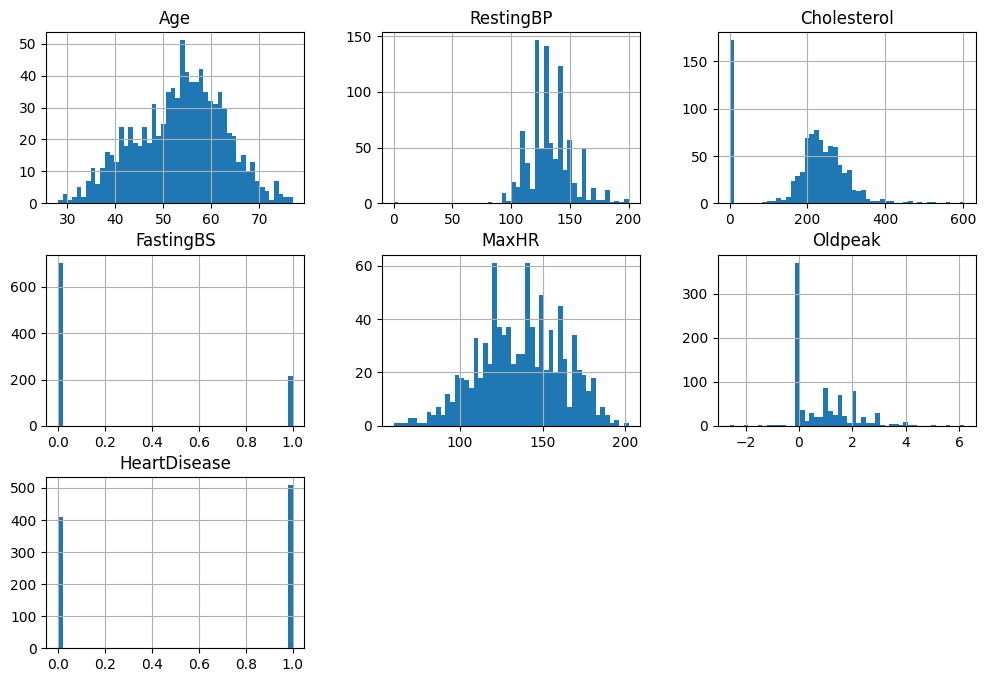

In [34]:
df.hist(bins=50, figsize=(12,8))

In [35]:
print("Duplicates:" , df.duplicated().sum())

Duplicates: 0


In [36]:
print((df['RestingBP'] == 0).sum())
print((df['Cholesterol'] == 0).sum())

1
172


In [37]:
pd.crosstab(
    df["Cholesterol"] == 0,
    df["HeartDisease"],
    margins=True
)

HeartDisease,0,1,All
Cholesterol,,,
False,390,356,746
True,20,152,172
All,410,508,918


In [38]:
# Calculate the median of Cholesterol, excluding the 0 values
median_cholesterol = df[df['Cholesterol'] != 0]['Cholesterol'].median()

# Replace 0 values in Cholesterol with the calculated median
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

print(f"Median Cholesterol (excluding 0s): {median_cholesterol}")
print("Number of 0 values in Cholesterol after imputation:", (df['Cholesterol'] == 0).sum())

Median Cholesterol (excluding 0s): 237.0
Number of 0 values in Cholesterol after imputation: 0


In [39]:
# Verify the change using crosstab
pd.crosstab(
    df["Cholesterol"] == median_cholesterol,
    df["HeartDisease"],
    margins=True
)

HeartDisease,0,1,All
Cholesterol,,,
False,388,352,740
True,22,156,178
All,410,508,918


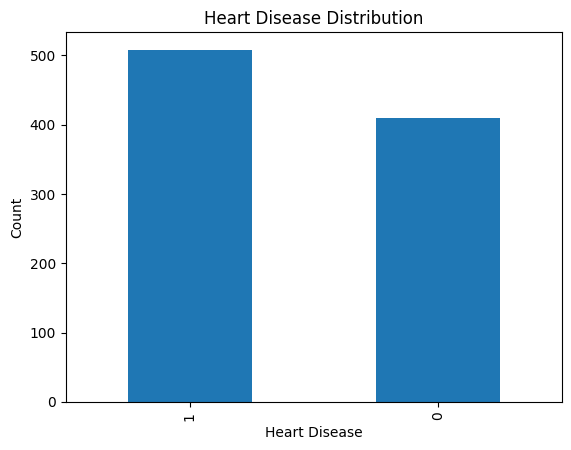

In [40]:
df["HeartDisease"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

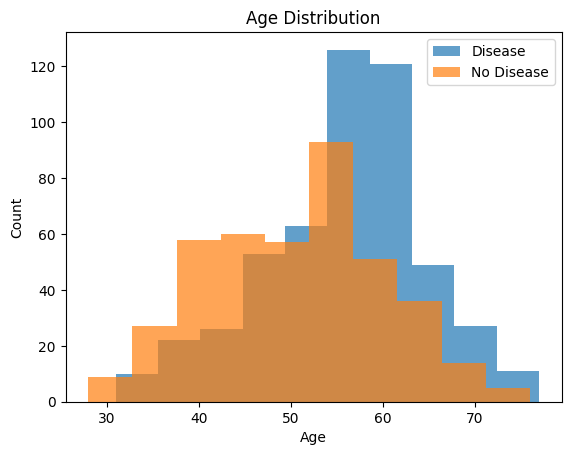

In [41]:
plt.hist(
    df[df["HeartDisease"] == 1]["Age"],
    alpha=0.7,
    label="Disease"
)

plt.hist(
    df[df["HeartDisease"] == 0]["Age"],
    alpha=0.7,
    label="No Disease"
)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.legend()

plt.show()

<Axes: >

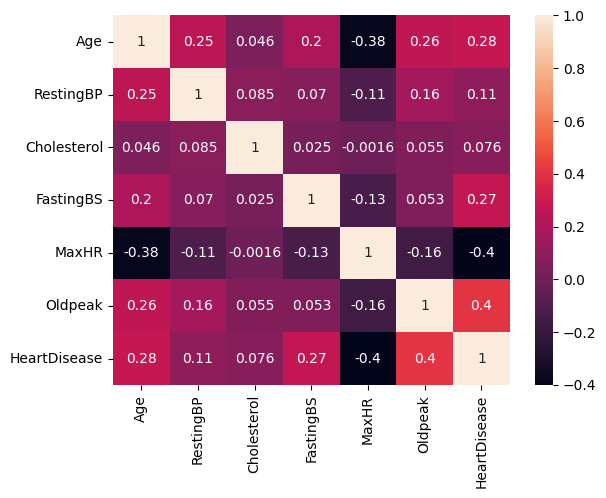

In [42]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)


In [43]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X = pd.get_dummies(X, drop_first=True)

print(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
0   40        140          289          0    172      0.0   True   
1   49        160          180          0    156      1.0  False   
2   37        130          283          0     98      0.0   True   
3   48        138          214          0    108      1.5  False   
4   54        150          195          0    122      0.0   True   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  \
0               True              False             False               True   
1              False               True             False               True   
2               True              False             False              False   
3              False              False             False               True   
4              False               True             False               True   

   RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  
0          False             False          F

In [44]:
rf_default = RandomForestClassifier(
    random_state=42
)

rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

print(
    "Baseline Accuracy:",
    accuracy_score(y_test, y_pred_default)
)

Baseline Accuracy: 0.875


In [45]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Recall:")
print(grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best Recall:
0.9013249021379102


In [46]:
y_pred_rf = best_model.predict(X_test)
y_prob_rf = best_model.predict_proba(X_test)[:, 1]

In [47]:
print(classification_report( y_test, y_pred_rf ))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84        82
           1       0.87      0.86      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



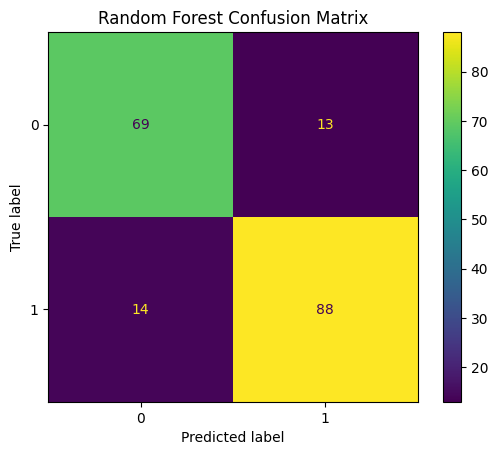

In [48]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

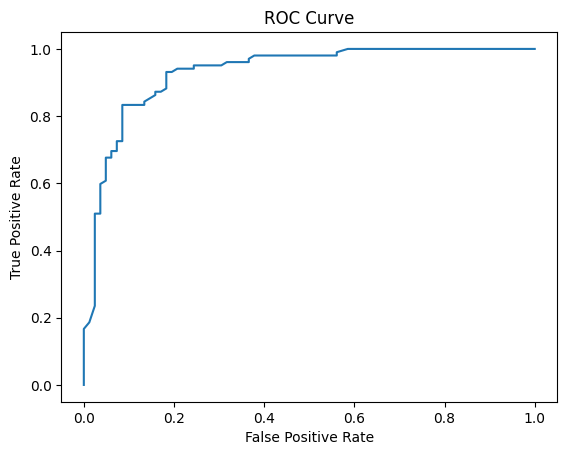

In [49]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

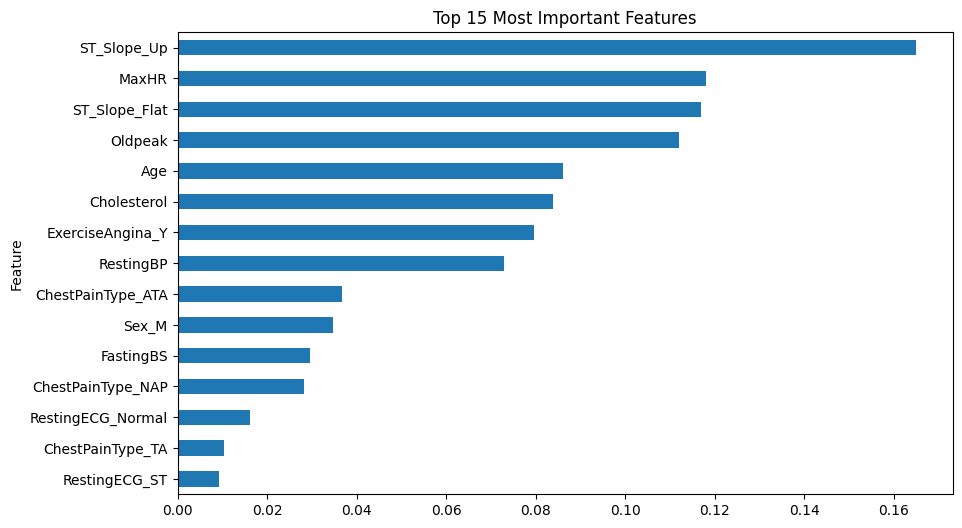

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

feature_importance.head(15).sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(10,6)
)

plt.title(
    "Top 15 Most Important Features"
)

plt.show()

In [51]:
results = pd.DataFrame({
    "Model": [
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_rf
        )
    ],
    "Recall": [
        recall_score(
            y_test,
            y_pred_rf
        )
    ],
    "Precision": [
        precision_score(
            y_test,
            y_pred_rf
        )
    ],
    "F1 Score": [
        f1_score(
            y_test,
            y_pred_rf
        )
    ],
    "ROC AUC": [
        roc_auc_score(
            y_test,
            y_prob_rf
        )
    ]
})

# Calculate the mean of Accuracy, Recall, Precision, and F1 Score
results['Mean Score'] = results[['Accuracy', 'Recall', 'Precision', 'F1 Score']].mean(axis=1)

results.sort_values(
    "Mean Score", # Sort by the new 'Mean Score'
    ascending=False
)

,Model,Accuracy,Recall,Precision,F1 Score,ROC AUC,Mean Score
0,Random Forest,0.853261,0.862745,0.871287,0.866995,0.930536,0.863572


### Feature Selection based on Importance


In [52]:

importance_threshold = 0.025

selected_features = feature_importance[feature_importance['Importance'] > importance_threshold]['Feature'].tolist()

print(f"Selected {len(selected_features)} features (importance > {importance_threshold}):\n{selected_features}")

X_selected = X[selected_features]

print("\nHead of X_selected:")
display(X_selected.head())

Selected 12 features (importance > 0.025):
['ST_Slope_Up', 'MaxHR', 'ST_Slope_Flat', 'Oldpeak', 'Age', 'Cholesterol', 'ExerciseAngina_Y', 'RestingBP', 'ChestPainType_ATA', 'Sex_M', 'FastingBS', 'ChestPainType_NAP']

Head of X_selected:


,ST_Slope_Up,MaxHR,ST_Slope_Flat,Oldpeak,Age,Cholesterol,ExerciseAngina_Y,RestingBP,ChestPainType_ATA,Sex_M,FastingBS,ChestPainType_NAP
0,True,172,False,0.0,40,289,False,140,True,True,0,False
1,False,156,True,1.0,49,180,False,160,False,False,0,True
2,True,98,False,0.0,37,283,False,130,True,True,0,False
3,False,108,True,1.5,48,214,True,138,False,False,0,False
4,True,122,False,0.0,54,195,False,150,False,True,0,True


In [53]:
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape of X_train_selected:", X_train_selected.shape)
print("Shape of X_test_selected:", X_test_selected.shape)

Shape of X_train_selected: (734, 12)
Shape of X_test_selected: (184, 12)


#### Baseline Random Forest Model with Selected Features

In [54]:
rf_default_selected = RandomForestClassifier(
    random_state=42
)

rf_default_selected.fit(X_train_selected, y_train_selected)

y_pred_default_selected = rf_default_selected.predict(X_test_selected)

print(
    "Baseline Accuracy with Selected Features:",
    accuracy_score(y_test_selected, y_pred_default_selected)
)

Baseline Accuracy with Selected Features: 0.8315217391304348


#### Hyperparameter Tuning for Random Forest with Selected Features

In [55]:
param_grid_selected = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search_selected = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid_selected,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_selected.fit(X_train_selected, y_train_selected)

best_model_selected = grid_search_selected.best_estimator_

print("Best Parameters with Selected Features:")
print(grid_search_selected.best_params_)

print("\nBest Recall with Selected Features:")
print(grid_search_selected.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters with Selected Features:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Best Recall with Selected Features:
0.8939174947305029


In [56]:
y_pred_rf_selected = best_model_selected.predict(X_test_selected)
y_prob_rf_selected = best_model_selected.predict_proba(X_test_selected)[:, 1]

#### Classification Report for Random Forest with Selected Features

In [57]:
print(classification_report( y_test_selected, y_pred_rf_selected ))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.87      0.85      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



#### Confusion Matrix for Random Forest with Selected Features

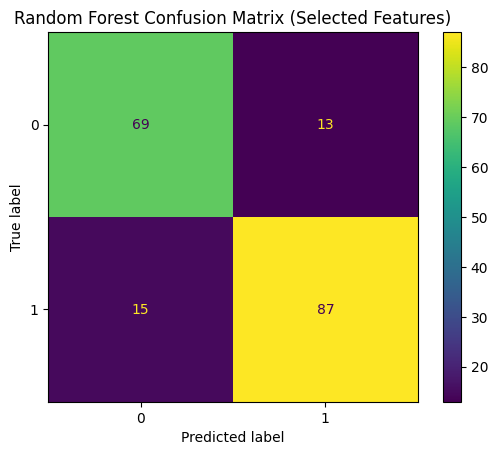

In [58]:
cm_selected = confusion_matrix(
    y_test_selected,
    y_pred_rf_selected
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_selected
).plot()

plt.title(
    "Random Forest Confusion Matrix (Selected Features)"
)

plt.show()

#### ROC Curve for Random Forest with Selected Features

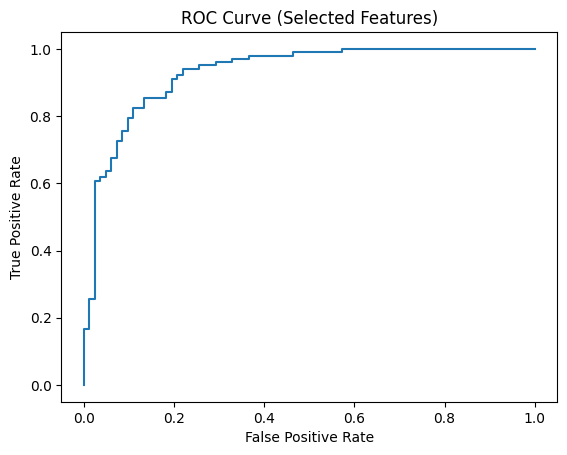

In [59]:
fpr_selected, tpr_selected, _ = roc_curve(
    y_test_selected,
    y_prob_rf_selected
)

plt.plot(fpr_selected, tpr_selected)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Selected Features)")

plt.show()

#### Compare Results: Original Features vs. Selected Features

In [60]:
results_selected = pd.DataFrame({
    "Model": [
        "Random Forest (Selected Features)"
    ],
    "Accuracy": [
        accuracy_score(
            y_test_selected,
            y_pred_rf_selected
        )
    ],
    "Recall": [
        recall_score(
            y_test_selected,
            y_pred_rf_selected
        )
    ],
    "Precision": [
        precision_score(
            y_test_selected,
            y_pred_rf_selected
        )
    ],
    "F1 Score": [
        f1_score(
            y_test_selected,
            y_pred_rf_selected
        )
    ],
    "ROC AUC": [
        roc_auc_score(
            y_test_selected,
            y_prob_rf_selected
        )
    ]
})

results_selected['Mean Score'] = results_selected[['Accuracy', 'Recall', 'Precision', 'F1 Score']].mean(axis=1)

# Combine and display both results dataframes
combined_results = pd.concat([results, results_selected])
display(combined_results.sort_values("Mean Score", ascending=False))

,Model,Accuracy,Recall,Precision,F1 Score,ROC AUC,Mean Score
0,Random Forest,0.853261,0.862745,0.871287,0.866995,0.930536,0.863572
0,Random Forest (Selected Features),0.847826,0.852941,0.870000,0.861386,0.929579,0.858038
